<a href="https://colab.research.google.com/github/ALDO12062004/EDP2/blob/main/Ecuaci%C3%B3n_de_onda_M%C3%A9todo_expl%C3%ADcito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECUACION DE ONDA
$$\frac{\partial^2 U}{\partial t^2}(x,t) - 4\frac{\partial^2 U}{\partial x^2 }(x,t) = 0, \quad 0<x<1, \quad t>0$$

con condiciones de frontera

$$u(0,t)=u(1,t)=0, \quad \text{ para } t>0$$

Y con condiciones iniciales

$$u(x,0) = sen(\pi x), \quad 0 \leq x \leq 1$$

y $$\quad \frac{\partial U}{\partial t}(x,0) = 0, \quad 0\leq x \leq 1$$

Usando $$h=0.1 \quad $ y $\quad k=0.05 \quad $$

Compare los resultados con la solución exacta.

$$u(x,t) = sen(\pi x)cos(2\pi t)$$

---

***Solución:***

Se usa la ecuaicón de diferencias finitas:

$$U_{i,j+1} = \lambda U_{i-1,j} + \lambda U_{i+1,j} + (2-2\lambda)U_{i,j} - U_{i,j-1}$$

Con $$\lambda=\alpha^2\frac{k^2}{h^2}$$

Obteniendo una forma matricial de la forma:

$$U^{n+1}=AU^{n} - U^{n-1}$$

Con A una matriz tridiagonal.

$$U^{n-1} \quad \text{se calcula con la condición inicial}  \quad f(x)$$

$$U^{n} \quad  \text{se calcula con la condición de primer orden} \quad g(x)$$

Para la condición de primer orden en diferencias finitas se utiliza:

$$U_{i,1} = U_{i,0} + kg(x) \quad$ para $\quad i=1,2,...,m-1$$

Notemos que por ser un método explicito con todo el lado derecho conocido no se tiene que resolver ningún tipo de sistema de ecuaciones, sino sólo hacer sustituciones.

In [ ]:
import sympy as sp
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

from matplotlib.animation import FuncAnimation # Para crear animaciones de gráficos
from IPython.display import HTML # Para mostrar animaciones en Jupyter/Colab

Se importan las librerias numpy y sympy para hacer los cálculos necesarios y definir funciones, el resto son para graficar

In [ ]:
def f(x):
  return np.sin(np.pi*x)

Se define la condición inicial $f(x)=sen(\pi x)$ en $t=0$

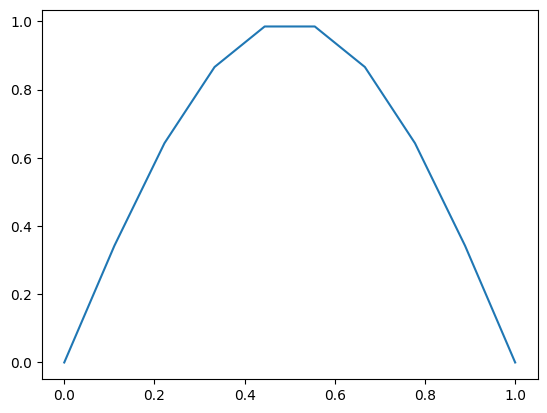

In [ ]:
x = np.linspace(0,1,10)
plt.plot(x,f(x))

Gráfica con 10 puntos de la condición inicial

In [ ]:
g = lambda xi: 0

Se define la condicion $$\frac{\partial U}{\partial t}(x,0)=g(x)=0$$

In [ ]:
def tridiagonal(n,a,b):
    return sp.Matrix([
    [a if i == j else b if abs(i-j) == 1 else 0 for j in range(n)]
    for i in range(n)
])

Función para llenar una matriz tridiagonal de tamaño n dando como valores de entrada a, b y n, donde a es la diagonal y b son las diagonales superior e inferior

In [ ]:
h=0.1
k=0.05
alpha = 4
lam = alpha * k**2/h**2
n=9

A = tridiagonal(9,2*(1-lam),lam)
A

Matrix([
[0.0, 1.0,   0,   0,   0,   0,   0,   0,   0],
[1.0, 0.0, 1.0,   0,   0,   0,   0,   0,   0],
[  0, 1.0, 0.0, 1.0,   0,   0,   0,   0,   0],
[  0,   0, 1.0, 0.0, 1.0,   0,   0,   0,   0],
[  0,   0,   0, 1.0, 0.0, 1.0,   0,   0,   0],
[  0,   0,   0,   0, 1.0, 0.0, 1.0,   0,   0],
[  0,   0,   0,   0,   0, 1.0, 0.0, 1.0,   0],
[  0,   0,   0,   0,   0,   0, 1.0, 0.0, 1.0],
[  0,   0,   0,   0,   0,   0,   0, 1.0, 0.0]])

Definimos los escalares que requiere el problema inicialmente para calcular los valores de la diagonal principal, inferior y superior.
Y se muestra la matriz A obtenida a partir de la ecuación de diferencias finitas una vez ya aplicados los valores para cada constante

In [ ]:
b = sp.Matrix([f(0.1*(i+1)) for i in range(n)])

vector b que corresponde a los valores en el tiempo $t=0$

In [ ]:
b

Matrix([
[0.309016994374947],
[0.587785252292473],
[0.809016994374947],
[0.951056516295154],
[              1.0],
[0.951056516295154],
[0.809016994374947],
[0.587785252292473],
[0.309016994374948]])

In [ ]:
Un = []
for i in range(n):
    Un_i = b[i] + k*g(h*(i+1)) #forma de calcular el vector usando condición de primer orden en diferencias finitas
    Un.append(Un_i)
Un = sp.Matrix(Un) # Convertir a Matrix de SymPy
Un

Matrix([
[0.309016994374947],
[0.587785252292473],
[0.809016994374947],
[0.951056516295154],
[              1.0],
[0.951056516295154],
[0.809016994374947],
[0.587785252292473],
[0.309016994374948]])

Se define el vector conocido obtenido a través de la condición de primer orden $g(x)$ y por ser ésta 0 dicho vector es igual al vector b

In [ ]:
def ecuacion_onda(A, Un, b, j):
    b= sp.Matrix(b)
    Un= sp.Matrix(Un)

    S = [b,Un]

    for n in range(2,j):
        sol = A*S[n-1] - S[n-2]
        S.append(sol)

    return sp.Matrix([s.T for s in S])

Se define la forma en que se sutituye cada iteración para ir obteniendo los pisos o diferentes tiempos, sin resolver ningún sistema, sino sólo sustituir

In [ ]:
j=10

Damos el número de iteraciones que hara, en $t$ que aumenta en $0.05$ por lo que 10 iteraciones llega a $t=0.5$

In [ ]:
U = ecuacion_onda(A, Un, b, j)

Se llama a la función para sustituir los valores y obtener el resultado, dando como valores de entrada la matriz A, el vector Un y el vector b, así como el número de iteraciones

# Ejercicio 1
Generar las gráficas 2D y 3D de la solución hasta t=0.50

In [ ]:
U_np = np.array(U.tolist(),dtype=float) #convierte una lista en un arreglo para poder graficarlo

Convertimos a U en un vector numpy sirve para convertir la lista U en un arreglo NumPy 2D uniforme, para graficar o animar.

In [ ]:
x = np.linspace(0, 1, 9)
y = np.linspace(0, 0.5, j)
X, Y = np.meshgrid(x, y)

Para las gráficas se definen los parametros de los ejes x,y y sus puntos que tendrán

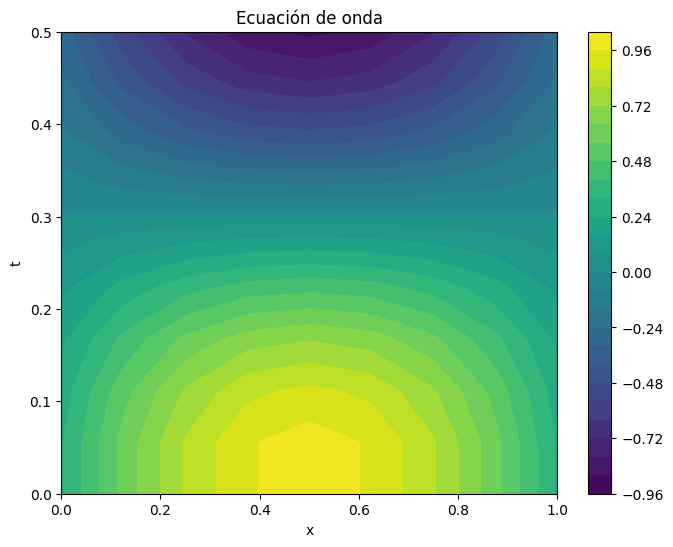

In [ ]:
# Graficar
plt.figure(figsize=(8, 6))
contour = plt.contourf(X, Y, U_np, levels=25, cmap=cm.viridis)
plt.colorbar(contour)
plt.title('Ecuación de onda')
plt.xlabel('x')
plt.ylabel('t')
plt.show()

Gráfica de mapa de colores de la solución de U para 10 iteraciones. Se observan figuras simétricas con una forma un poco extraña, ya no son simples arcos

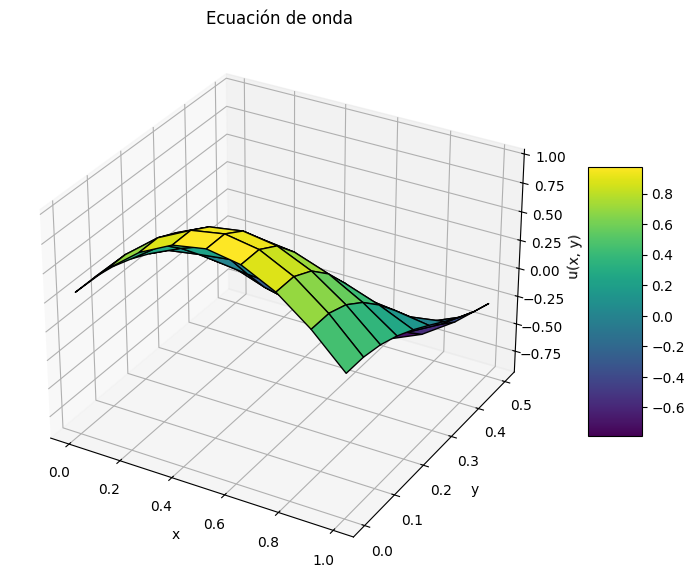

In [ ]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, U_np, cmap=cm.viridis, edgecolor='k')
ax.set_title('Ecuación de onda')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u(x, y)')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

Sólo se ve una parte de la gráfica debido a las pocas iteraciones, pero parece que son oscilatorias, del tipo seno o coseno

# Ejercicio 2
 Comparar los valores correspondientes su solución numérica con los resultados numéricos que proporciona la Tabla 12.6, que viene en la imagen adjunta. Graficar y calcular el error.


In [ ]:
j=20

Para que coincida con la tabla proporcionada, se hacen 20 iteraciones, es decir, para $t=1$

In [ ]:
U=ecuacion_onda(A,Un,b,j)

Se resuelve para 20 iteraciones

In [ ]:
U_np = np.array(U.tolist(),dtype=float) #Convierte una lista en un arreglo para poder graficarlo

Se vuelve a convertir a U en un vector numpy sirve para graficar.

In [ ]:
U_np[19] #comienza en 0 por lo que la iteración 20 es 19

array([0.27876826, 0.53024874, 0.72982477, 0.85796048, 0.90211303,
       0.85796048, 0.72982477, 0.53024874, 0.27876826])

Aproximación en $t=1$ que corresponde exactamente a los valores proporcionados en la tabla

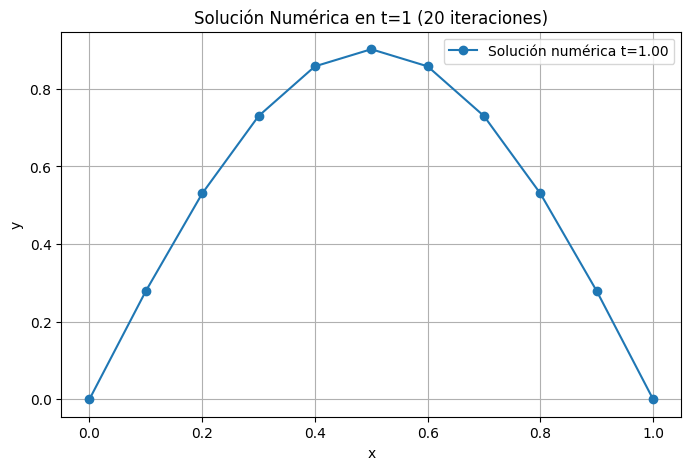

In [ ]:
# Crear malla de puntos x1 según el tamaño de la solución (nodos interiores)
n = U_np.shape[1]  # número de incógnitas
x_num = np.linspace(h, 1-h, n) #los puntos comienzan en h=0.1 y terminan en 1-h=0.9
x_ex = np.linspace(0,1,200)  # malla fina para la solución exacta

# Agregar puntos de frontera para la solución numérica
x_completo = np.concatenate(([0], x_num, [1])) #para incluir las fronteras x=0 y x=1
U_completo = np.concatenate(([0], U_np[j-1], [0])) #valor de u(0,t)=u(1,t)=0, y se toma la última fila (j-1)

plt.figure(figsize=(8,5))
plt.plot(x_completo, U_completo, 'o-', label=f'Solución numérica t={j*k:.2f}')
plt.title('Solución Numérica en t=1 (20 iteraciones)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Gráfica de la aproximación en el tiempo $t=1$

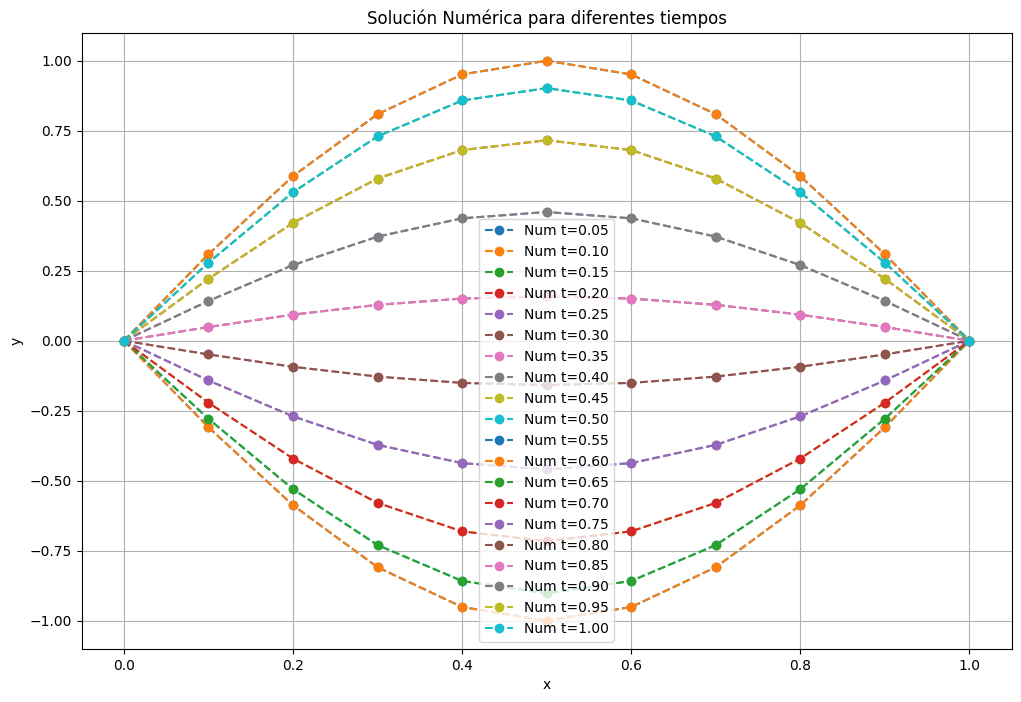

In [ ]:
# Crear malla de puntos x1 según el tamaño de la solución (nodos interiores)
n = U_np.shape[1]  # número de incógnitas
x_num = np.linspace(h, 1-h, n) #los puntos comienzan en h=0.1 y terminan en 1-h=0.9
x_ex = np.linspace(0,1,200) #para solucióin exacta

# Agregar puntos de frontera para la solución numérica
x_completo = np.concatenate(([0], x_num, [1])) #para incluir las fronteras x=0 y x=1
plt.figure(figsize=(12, 8)) #Para hacer la gráfica más grande y se noten las comparativas

for i in range(j):
    t_act = (i + 1) * k #variación de los t

    #Solución numérica
    U_fila_act = U_np[i] # sacamos la información de la lista U para iterar
    U_completo_act = np.concatenate(([0], U_fila_act, [0])) # Para agregar las fronteras en cada iteración
    plt.plot(x_completo, U_completo_act, 'o--', label=f'Num t={t_act:.2f}')

plt.title('Solución Numérica para diferentes tiempos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Gráfica donde se aprecian los 20 tiempos de $t=0 $ a $t=1$ con un aumento de k, nótemos que es una función oscilatoria, por lo que algunos valores coinciden y la curva se sobrepone a otro valor de $t$, pero todos los valores en esos rangos lanzan esas aproximaciones

#Ejercicio 3

 Comparar esos mismos valores contra la solución exacta de la ecuación. Graficar y calcular el error. Discutir la comparación.


In [ ]:
def u_exact(x,t):
  return np.sin(np.pi*x)*np.cos(2*np.pi*t)

Definimos la solución exacta de la ecuación de onda

In [ ]:
x=np.linspace(0,1,100)
y=np.linspace(0,1,21)
X,Y=np.meshgrid(x,y)

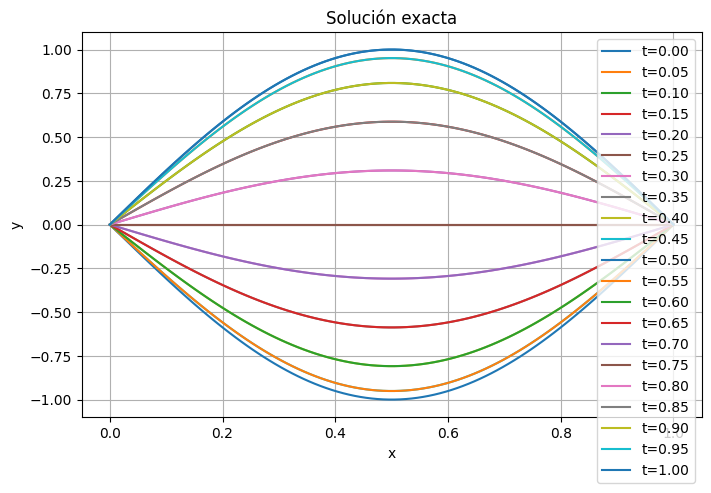

In [ ]:
plt.figure(figsize=(8,5))

for t in y:
  plt.plot(x,u_exact(x,t), label=f"t={t:.2f}")

plt.title("Solución exacta")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

Gráfica de la solución exacta para los mismos valores de t, donde igual se aprecia que algunas gráficas se sobreponen a otra de distinto tiempo, por lo que se concluye que la solución es oscilatoria

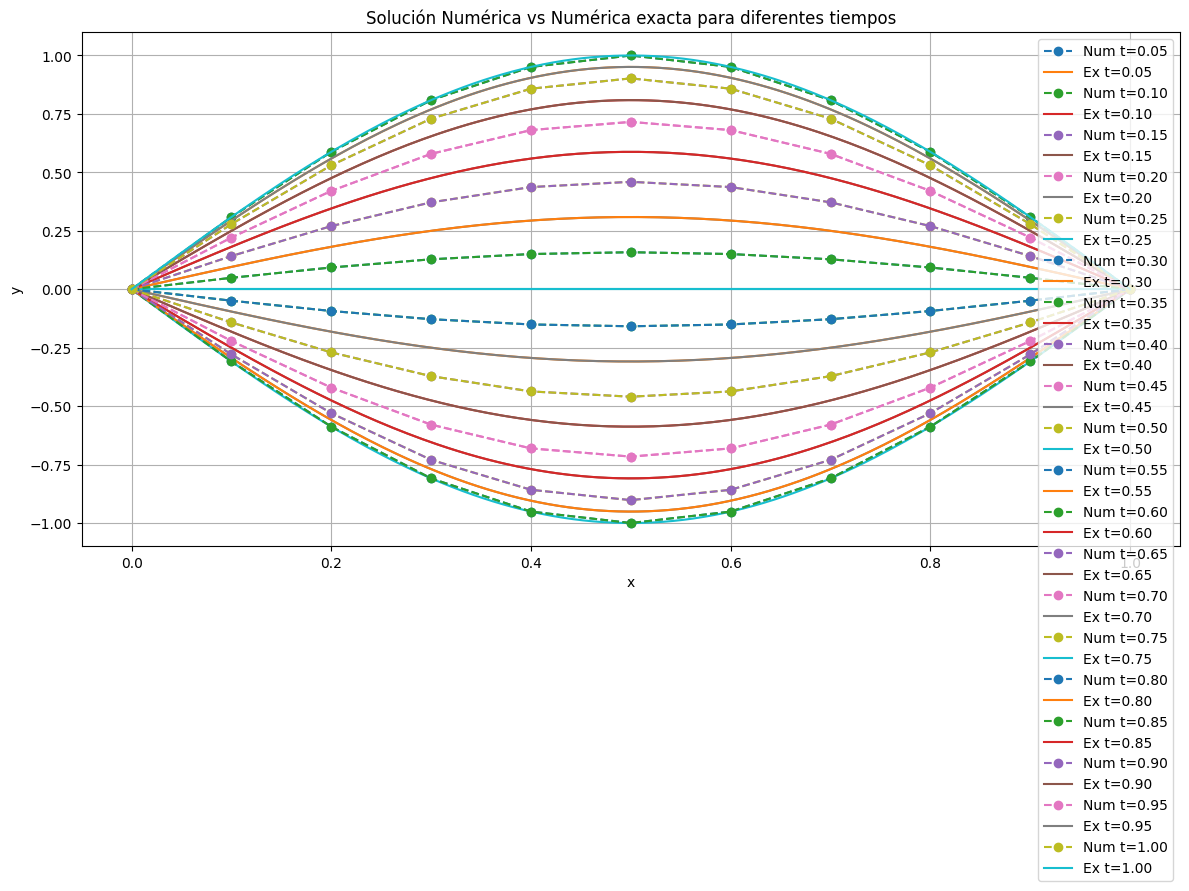

In [ ]:
# Crear malla de puntos x1 según el tamaño de la solución (nodos interiores)
n = U_np.shape[1]  # número de incógnitas
x_num = np.linspace(h, 1-h, n) #los puntos comienzan en h=0.1 y terminan en 1-h=0.9
x_ex = np.linspace(0,1,200) #para solucióin exacta

# Agregar puntos de frontera para la solución numérica
x_completo = np.concatenate(([0], x_num, [1])) #para incluir las fronteras x=0 y x=1
plt.figure(figsize=(12, 8)) #Para hacer la gráfica más grande y se noten las comparativas

for i in range(j):
    t_act = (i + 1) * k #variación de los t

    #Solución numérica
    U_fila_act = U_np[i] # sacamos la información de la lista U para iterar
    U_completo_act = np.concatenate(([0], U_fila_act, [0])) # Para agregar las fronteras en cada iteración
    plt.plot(x_completo, U_completo_act, 'o--', label=f'Num t={t_act:.2f}')

    # Solución exacta
    plt.plot(x_ex, u_exact(x_ex, t_act), '-', label=f'Ex t={t_act:.2f}')

plt.title('Solución Numérica vs Numérica exacta para diferentes tiempos')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.tight_layout() #Ajusta las dimensiones de la gráfica
plt.show()

Comparativa de la solución aproximada y la numérica, se aprecia la variación que hay que para valores pequeños, mientras que para los valores cercanos a 1 comienzan a parecerse las gráficas

In [ ]:
norm = []

for i in range(j):
    t_act = (i + 1) * k #variación de los t

    U_fila_act = np.array(U_np[i], dtype=float) #Solución numérica

    u_exact_act = np.array(u_exact(x_num, t_act), dtype=float) #Solución exacta

    dif = U_fila_act - u_exact_act #Diferencia de vectores para cada t

    l2_norm = np.linalg.norm(dif) #Norma 2 de cada vector t
    norm.append(l2_norm)

print("Error:")
for i, norm_val in enumerate(norm):
    print(f"t={(i+1)*k:.2f}: {norm_val:.6f}")

Error:
t=0.05: 0.109441
t=0.10: 0.427051
t=0.15: 0.702858
t=0.20: 0.909865
t=0.25: 1.027808
t=0.30: 1.045141
t=0.35: 0.960169
t=0.40: 0.781209
t=0.45: 0.525779
t=0.50: 0.218882
t=0.55: 0.109441
t=0.60: 0.427051
t=0.65: 0.702858
t=0.70: 0.909865
t=0.75: 1.027808
t=0.80: 1.045141
t=0.85: 0.960169
t=0.90: 0.781209
t=0.95: 0.525779
t=1.00: 0.218882


De cada vector obtenido en cada paso t se resta el de la solución aproximada con el de la solución numérica y se obtienen 20 vectores a los cuales se calcula la norma 2 para saber el error de cada piso (valor de t)

#Ejercicio 4

Genere una animación de la evolución temporal de la solución, donde efectivamente se observen las ondulaciones de la onda.

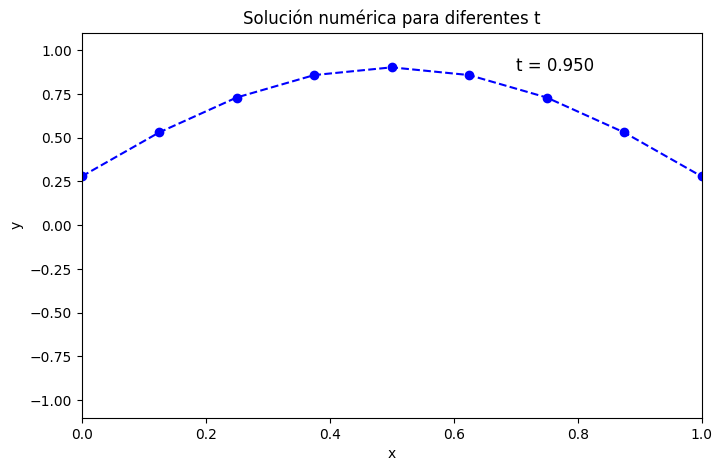

In [ ]:
x = np.linspace(0, 1, U_np.shape[1])

fig, ax = plt.subplots(figsize=(8,5))
line, = ax.plot([], [], 'o--', color='blue')
ax.set_xlim(0, 1)
ax.set_ylim(np.min(U_np)-0.1, np.max(U_np)+0.1)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Solución numérica para diferentes t")

time_text = ax.text(0.7, 0.9, '', transform=ax.transAxes, fontsize=12)

# Función de inicialización de la animación
def init():
    line.set_data([], [])
    time_text.set_text('') # El texto de tiempo está vacío
    return line, time_text # Retornamos los objetos que se van a animar

def update(frame):
    line.set_data(x, U_np[frame])  # Actualiza la línea con los valores de U_np en el frame actual
    time_text.set_text(f"t = {y[frame]:.3f}") # Actualiza el texto con el tiempo correspondiente
    return line, time_text

# Definimos los frames de la animación (uno por cada fila de U_np)
frames = np.arange(U_np.shape[0])  # 0,1,...,19

# Creación de la animación
ani = FuncAnimation(fig, update, frames=frames, init_func=init,
                    interval=120, blit=True)


# Muestra la animación en un Jupyter Notebook o Colab
HTML(ani.to_jshtml())

La animación se hizo especificamente en y para COLAB, por lo que desconozco si se pueda ejecutar en algún otro sitio, pero se aprecia la forma en que la gráfica se encuentra entre -1 y 1 formando pequeños arcos